<a href="https://colab.research.google.com/github/Ganapathirajan/INTERNSHIP-PROJECT/blob/main/INTERNSHIP_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ** INTERNSHIP PROJECT **
Dataset    : Wisconsin Diagnostic Breast Cancer (UCI / sklearn built-in)

Task       : Binary Classification — Malignant (M) vs Benign (B)

Models     : Logistic Regression, Random Forest, SVM, KNN

Evaluation : Accuracy, ROC-AUC, Confusion Matrix, Classification Report

Author     : GANAPATHIRAJAN P





LOADING DATASET

  Samples  : 569
  Features : 30
  Classes  : {'benign': 357, 'malignant': 212}

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  mean compactness  mean concavity  mean concave points  mean symmetry  mean fractal dimension  radius error  texture error  perimeter error  area error  smoothness error  compactness error  concavity error  concave points error  symmetry error  fractal dimension error  worst radius  worst texture  worst perimeter  worst area  worst smoothness  worst compactness  worst concavity  worst concave points  worst symmetry  worst fractal dimension  diagnosis
0        17.99         10.38           122.8     1001.0          0.11840           0.27760          0.3001              0.14710         0.2419                 0.07871        1.0950         0.9053            8.589      153.40          0.006399            0.04904          0.05373               0.01587         0.03003                 0.006193         25.38          17.33    

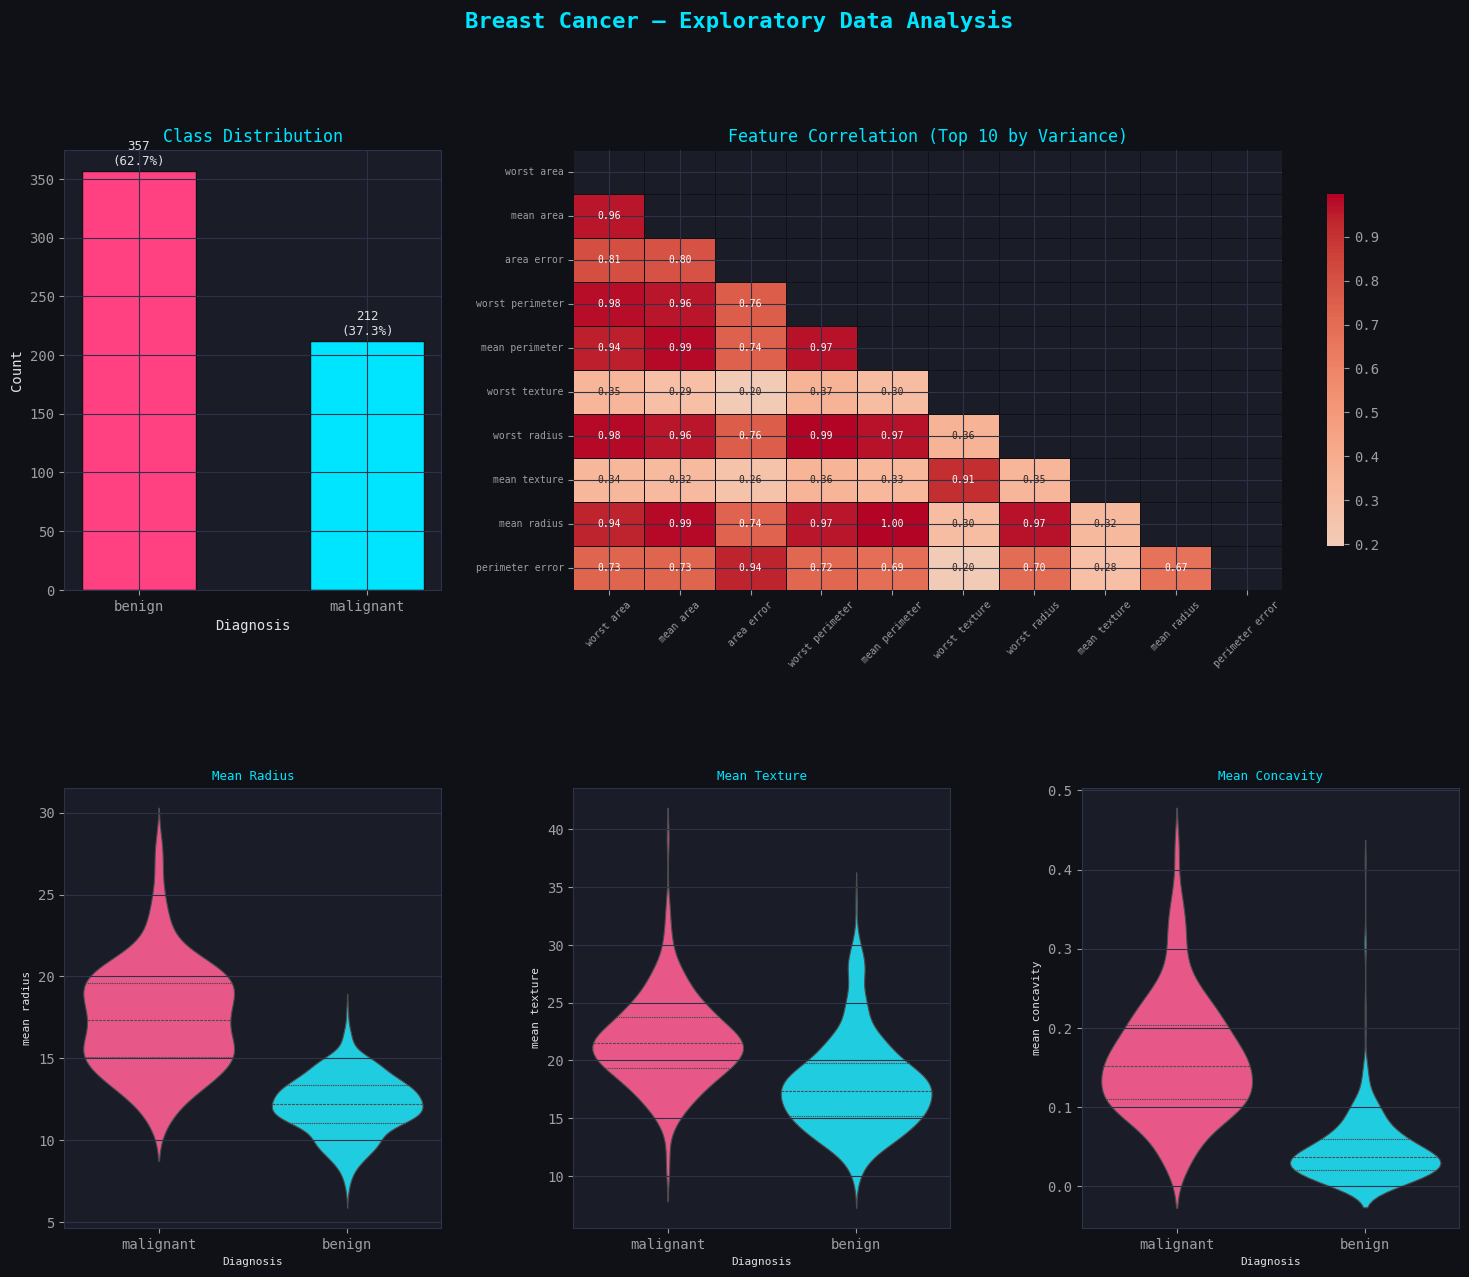


  [✓] EDA figure saved → eda_overview.png
PREPROCESSING & TRAIN-TEST SPLIT

  Train samples : 398
  Test  samples : 171
  Features      : 30
  Class balance (train): {np.int64(0): np.int64(250), np.int64(1): np.int64(148)}
TRAINING CLASSIFIERS

  [Logistic Regression]
    Accuracy  : 0.9766
    ROC-AUC   : 0.9971
    CV AUC    : 0.9940 ± 0.0052

  [Random Forest]
    Accuracy  : 0.9474
    ROC-AUC   : 0.9880
    CV AUC    : 0.9903 ± 0.0105

  [SVM (RBF)]
    Accuracy  : 0.9649
    ROC-AUC   : 0.9963
    CV AUC    : 0.9962 ± 0.0044

  [K-Nearest Neighbors]
    Accuracy  : 0.9532
    ROC-AUC   : 0.9766
    CV AUC    : 0.9934 ± 0.0087
BEST MODEL: Logistic Regression

  Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98       107
   Malignant       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98     

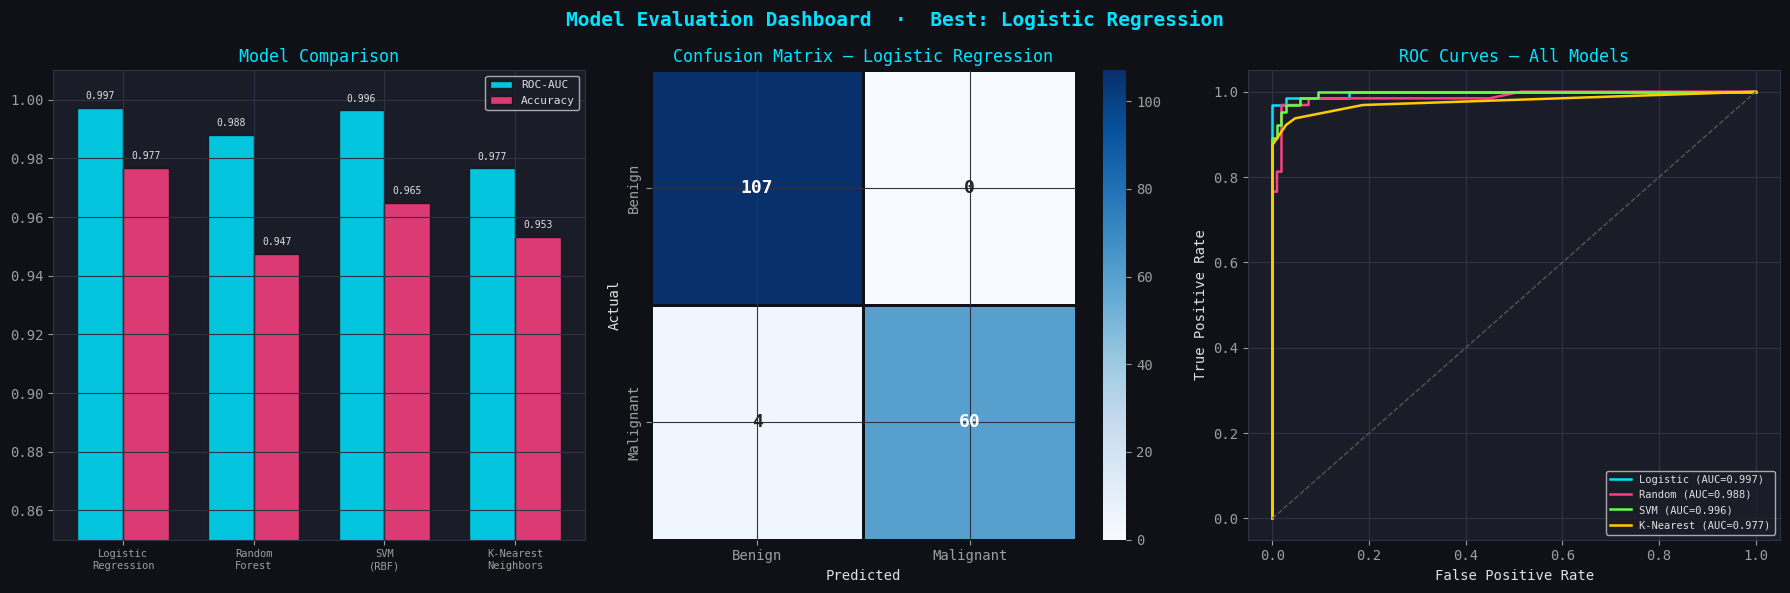


  [✓] Evaluation dashboard saved → evaluation_dashboard.png
FEATURE IMPORTANCE (Random Forest)


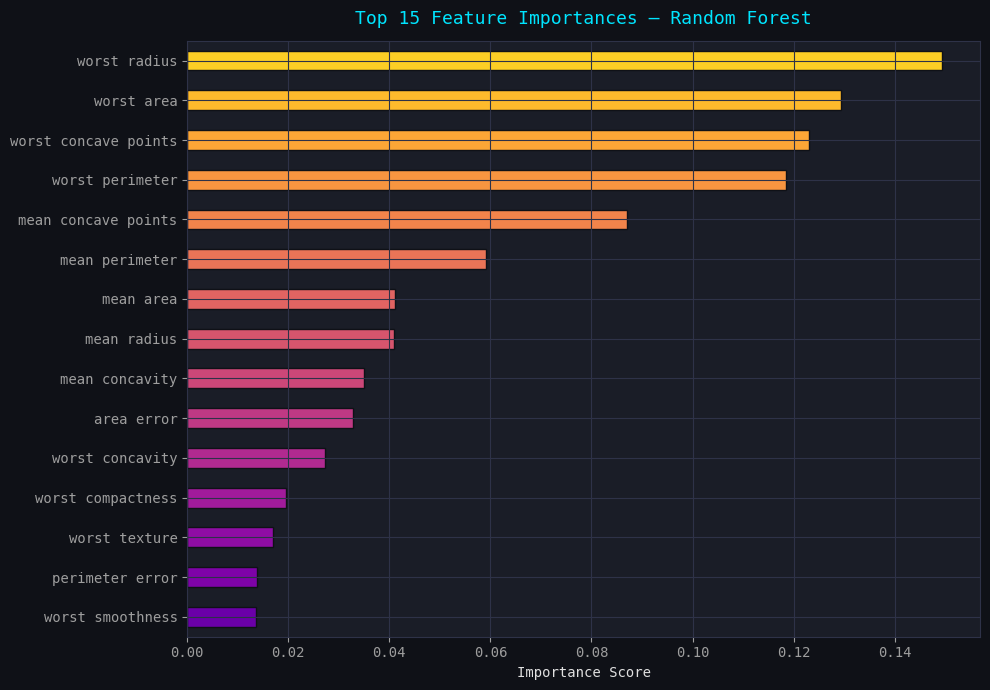


  Top 5 Predictive Features:
    worst radius                        0.1494
    worst area                          0.1295
    worst concave points                0.1230
    worst perimeter                     0.1186
    mean concave points                 0.0871

  [✓] Feature importance plot saved → feature_importance.png
FINAL SUMMARY

                    Accuracy ROC-AUC           CV-AUC
Model                                                
Logistic Regression   0.9766  0.9971  0.9940 ± 0.0052
Random Forest         0.9474  0.9880  0.9903 ± 0.0105
SVM (RBF)             0.9649  0.9963  0.9962 ± 0.0044
K-Nearest Neighbors   0.9532  0.9766  0.9934 ± 0.0087

  ★  Best Model → Logistic Regression  (ROC-AUC: 0.9971)
  PIPELINE COMPLETE


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

SEED = 2529
np.random.seed(SEED)
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.labelcolor":  "#e0e0e0",
    "xtick.color":      "#9e9e9e",
    "ytick.color":      "#9e9e9e",
    "text.color":       "#e0e0e0",
    "axes.edgecolor":   "#2e3248",
    "grid.color":       "#2e3248",
    "axes.grid":        True,
    "font.family":      "monospace",
})
PALETTE = ["#00e5ff", "#ff4081"]

# 1. LOAD & INSPECT DATASET

print("LOADING DATASET")

raw = load_breast_cancer()                      # 569 samples, 30 features
df  = pd.DataFrame(raw.data, columns=raw.feature_names)
df["diagnosis"] = pd.Categorical.from_codes(raw.target, ["malignant", "benign"])

print(f"\n  Samples  : {df.shape[0]}")
print(f"  Features : {df.shape[1] - 1}")
print(f"  Classes  : {df['diagnosis'].value_counts().to_dict()}")
print(f"\n{df.head(3).to_string()}")
print(f"\n{df.describe().T[['mean','std','min','max']].round(2).to_string()}")

# 2. EXPLORATORY DATA ANALYSIS

print("EXPLORATORY DATA ANALYSIS")

fig = plt.figure(figsize=(18, 14), facecolor="#0f1117")
fig.suptitle("Breast Cancer — Exploratory Data Analysis",
             fontsize=16, color="#00e5ff", fontweight="bold", y=0.98)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 2a. Class distribution
ax0 = fig.add_subplot(gs[0, 0])
counts = df["diagnosis"].value_counts()
bars = ax0.bar(counts.index, counts.values, color=PALETTE[::-1], edgecolor="#0f1117", width=0.5)
for bar, val in zip(bars, counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{val}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9, color="#e0e0e0")
ax0.set_title("Class Distribution", color="#00e5ff")
ax0.set_xlabel("Diagnosis")
ax0.set_ylabel("Count")

# 2b. Correlation heatmap (top 10 features by variance)

ax1 = fig.add_subplot(gs[0, 1:])
top10 = df.drop("diagnosis", axis=1).var().nlargest(10).index
corr  = df[top10].corr()
mask  = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax1, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.4, linecolor="#0f1117",
            cbar_kws={"shrink": 0.8})
ax1.set_title("Feature Correlation (Top 10 by Variance)", color="#00e5ff")
ax1.tick_params(axis="x", rotation=45, labelsize=7)
ax1.tick_params(axis="y", rotation=0,  labelsize=7)

# 2c–2e. Violin plots for 3 most discriminative features

key_feats = ["mean radius", "mean texture", "mean concavity"]
for idx, feat in enumerate(key_feats):
    ax = fig.add_subplot(gs[1, idx])
    sns.violinplot(data=df, x="diagnosis", y=feat,
                   palette={"malignant": PALETTE[1], "benign": PALETTE[0]},
                   inner="quartile", ax=ax, linewidth=0.8)
    ax.set_title(feat.title(), color="#00e5ff", fontsize=9)
    ax.set_xlabel("Diagnosis", fontsize=8)
    ax.set_ylabel(feat, fontsize=8)

plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("\n  [✓] EDA figure saved → eda_overview.png")

# 3. PREPROCESSING

print("PREPROCESSING & TRAIN-TEST SPLIT")

X = df.drop("diagnosis", axis=1)
y = (df["diagnosis"] == "malignant").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\n  Train samples : {X_train_s.shape[0]}")
print(f"  Test  samples : {X_test_s.shape[0]}")
print(f"  Features      : {X_train_s.shape[1]}")
print(f"  Class balance (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")

# 4. MODEL TRAINING — FOUR CLASSIFIERS

print("TRAINING CLASSIFIERS")

models = {
    "Logistic Regression" : LogisticRegression(max_iter=5000, random_state=SEED),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=SEED),
    "SVM (RBF)"           : SVC(kernel="rbf", probability=True, random_state=SEED),
    "K-Nearest Neighbors" : KNeighborsClassifier(n_neighbors=7),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, clf in models.items():
    clf.fit(X_train_s, y_train)
    y_pred  = clf.predict(X_test_s)
    y_prob  = clf.predict_proba(X_test_s)[:, 1]
    cv_scores = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring="roc_auc")

    results[name] = {
        "model"    : clf,
        "y_pred"   : y_pred,
        "y_prob"   : y_prob,
        "accuracy" : accuracy_score(y_test, y_pred),
        "roc_auc"  : roc_auc_score(y_test, y_prob),
        "cv_mean"  : cv_scores.mean(),
        "cv_std"   : cv_scores.std(),
    }
    print(f"\n  [{name}]")
    print(f"    Accuracy  : {results[name]['accuracy']:.4f}")
    print(f"    ROC-AUC   : {results[name]['roc_auc']:.4f}")
    print(f"    CV AUC    : {results[name]['cv_mean']:.4f} ± {results[name]['cv_std']:.4f}")

# 5. BEST MODEL — DETAILED REPORT

best_name = max(results, key=lambda k: results[k]["roc_auc"])
best      = results[best_name]

print(f"BEST MODEL: {best_name}")
print(f"\n  Classification Report:\n")
print(classification_report(y_test, best["y_pred"],
                             target_names=["Benign", "Malignant"]))

# 6. EVALUATION DASHBOARD

print("EVALUATION DASHBOARD")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#0f1117")
fig.suptitle(f"Model Evaluation Dashboard  ·  Best: {best_name}",
             fontsize=14, color="#00e5ff", fontweight="bold")

# 6a. Model comparison bar chart

ax = axes[0]
names  = list(results.keys())
aucs   = [results[n]["roc_auc"] for n in names]
accs   = [results[n]["accuracy"] for n in names]
x      = np.arange(len(names))
w      = 0.35
bars1  = ax.bar(x - w/2, aucs, w, label="ROC-AUC", color="#00e5ff", alpha=0.85, edgecolor="#0f1117")
bars2  = ax.bar(x + w/2, accs, w, label="Accuracy", color="#ff4081", alpha=0.85, edgecolor="#0f1117")
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", fontsize=7, color="#e0e0e0")
ax.set_xticks(x)
ax.set_xticklabels([n.replace(" ", "\n") for n in names], fontsize=7.5)
ax.set_ylim(0.85, 1.01)
ax.set_title("Model Comparison", color="#00e5ff")
ax.legend(fontsize=8)

# 6b. Confusion matrix (best model)

ax = axes[1]
cm  = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"],
            linewidths=1, linecolor="#0f1117",
            annot_kws={"size": 13, "weight": "bold"})
ax.set_title(f"Confusion Matrix — {best_name}", color="#00e5ff")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# 6c. ROC curves (all models)

ax = axes[2]
colors = ["#00e5ff", "#ff4081", "#69ff47", "#ffcc00"]
for (name, res), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, color=col, lw=1.8,
            label=f"{name.split()[0]} (AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1], "--", color="#555", lw=1)
ax.set_title("ROC Curves — All Models", color="#00e5ff")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=7.5, loc="lower right")

plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("\n  [✓] Evaluation dashboard saved → evaluation_dashboard.png")

# 7. FEATURE IMPORTANCE (Random Forest)

print("FEATURE IMPORTANCE (Random Forest)")

rf_model   = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15       = importances.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#0f1117")
colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, 15))
top15.plot.barh(ax=ax, color=colors_bar, edgecolor="#0f1117")
ax.set_title("Top 15 Feature Importances — Random Forest",
             color="#00e5ff", fontsize=13, pad=12)
ax.set_xlabel("Importance Score")
ax.set_facecolor("#1a1d27")
for spine in ax.spines.values():
    spine.set_edgecolor("#2e3248")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()

print("\n  Top 5 Predictive Features:")
for feat, score in importances.nlargest(5).items():
    print(f"    {feat:<35} {score:.4f}")

print("\n  [✓] Feature importance plot saved → feature_importance.png")

# 8. SUMMARY TABLE

print("FINAL SUMMARY")

summary = pd.DataFrame({
    "Model"    : list(results.keys()),
    "Accuracy" : [f"{v['accuracy']:.4f}" for v in results.values()],
    "ROC-AUC"  : [f"{v['roc_auc']:.4f}"  for v in results.values()],
    "CV-AUC"   : [f"{v['cv_mean']:.4f} ± {v['cv_std']:.4f}" for v in results.values()],
}).set_index("Model")

print(f"\n{summary.to_string()}")
print(f"\n  ★  Best Model → {best_name}  (ROC-AUC: {best['roc_auc']:.4f})")
print("  PIPELINE COMPLETE")